## 저장한 모델 사용하기

### 1. 라이브러리 로드

In [14]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import requests
from PIL import Image
from io import BytesIO
import os
import random
import shutil

# 사전학습 모델 라이브러리 추가
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# pip install icrawler
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler

import matplotlib.pyplot as plt

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.12.0+cu130
True
13.0
NVIDIA GeForce RTX 5060


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### 2. 설정

In [4]:
model_path = 'resnet18_bird_cat_dog.pth'
test_dir = 'dataset/test'

num_classes = 3
batch_size = 16

### 3. ResNet18 모델구조 재생성

In [5]:
weight = ResNet18_Weights.DEFAULT
model = resnet18(weights=weight)

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=num_classes
)

model = model.to(device=device)

### 4. pth 모델파일 로드

In [6]:
model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### 5. 전처리 설정

In [7]:
preprocess = weight.transforms()
preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 6. 바이두 이미지크롤링 
- 테스트이미지셋 다운로드

In [8]:
# 추가설정
testset_dir = 'dataset/test'

classes = {
    'dog photo': 'dog',
    'cat photo': 'cat',
    'bird photo': 'bird'
}

num_epoch = 5
lr = 0.001

In [ ]:
# 테스트이미지 폴더
# for keyword, class_name in classes.items():
#     save_dir = os.path.join(testset_dir, class_name)
#     os.makedirs(save_dir, exist_ok=True)

#     crawler = BaiduImageCrawler(
#         storage={'root_dir': save_dir}
#     )

#     crawler.crawl(
#         keyword=keyword,
#         max_num=150
#     )

### 7. test 데이터셋 불러오기

In [10]:
test_dataset = ImageFolder(
    root=testset_dir,
    transform=preprocess
)
test_dataset.classes

['bird', 'cat', 'dog']

In [11]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

### 8. test 정확도 확인

In [12]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predict = torch.max(outputs, 1)

        correct += (predict == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total

print(f'테스트 정확도 : {test_acc:.4f}')

테스트 정확도 : 0.9465


### 9. 실제/예측값 출력

In [13]:
class_names = test_dataset.classes

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        prob = torch.softmax(outputs, dim=1)
        confidence, predict = torch.max(prob, 1)

        for i in range(len(labels)):
            true_label = class_names[labels[i].item()]
            pred_label = class_names[predict[i].item()]
            conf = confidence[i].item()

            print(f'실제 : {true_label} / 예측 : {pred_label} / 확률 : {conf:.4f}')

실제 : bird / 예측 : bird / 확률 : 0.5095
실제 : bird / 예측 : bird / 확률 : 0.9688
실제 : bird / 예측 : bird / 확률 : 0.7699
실제 : bird / 예측 : bird / 확률 : 0.7473
실제 : bird / 예측 : bird / 확률 : 0.9168
실제 : bird / 예측 : bird / 확률 : 0.9541
실제 : bird / 예측 : bird / 확률 : 0.9819
실제 : bird / 예측 : bird / 확률 : 0.7450
실제 : bird / 예측 : bird / 확률 : 0.9731
실제 : bird / 예측 : bird / 확률 : 0.6504
실제 : bird / 예측 : bird / 확률 : 0.9702
실제 : bird / 예측 : bird / 확률 : 0.8762
실제 : bird / 예측 : bird / 확률 : 0.5766
실제 : bird / 예측 : bird / 확률 : 0.9965
실제 : bird / 예측 : bird / 확률 : 0.9642
실제 : bird / 예측 : bird / 확률 : 0.9545
실제 : bird / 예측 : bird / 확률 : 0.9922
실제 : bird / 예측 : bird / 확률 : 0.9238
실제 : bird / 예측 : bird / 확률 : 0.9748
실제 : bird / 예측 : bird / 확률 : 0.8026
실제 : bird / 예측 : bird / 확률 : 0.8433
실제 : bird / 예측 : bird / 확률 : 0.9842
실제 : bird / 예측 : bird / 확률 : 0.9525
실제 : bird / 예측 : bird / 확률 : 0.9669
실제 : bird / 예측 : bird / 확률 : 0.9490
실제 : bird / 예측 : bird / 확률 : 0.7106
실제 : bird / 예측 : bird / 확률 : 0.9561
실제 : bird / 예측 : bird / 확률 :

### 10. 시각화

2026-05-21 16:57:42,647 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.4134207].
2026-05-21 16:57:42,655 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.4308496].
2026-05-21 16:57:42,660 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.535425].
2026-05-21 16:57:42,668 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.64].
2026-05-21 16:57:42,675 - WARNING - matplotlib.image - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.5528543].
2026-0

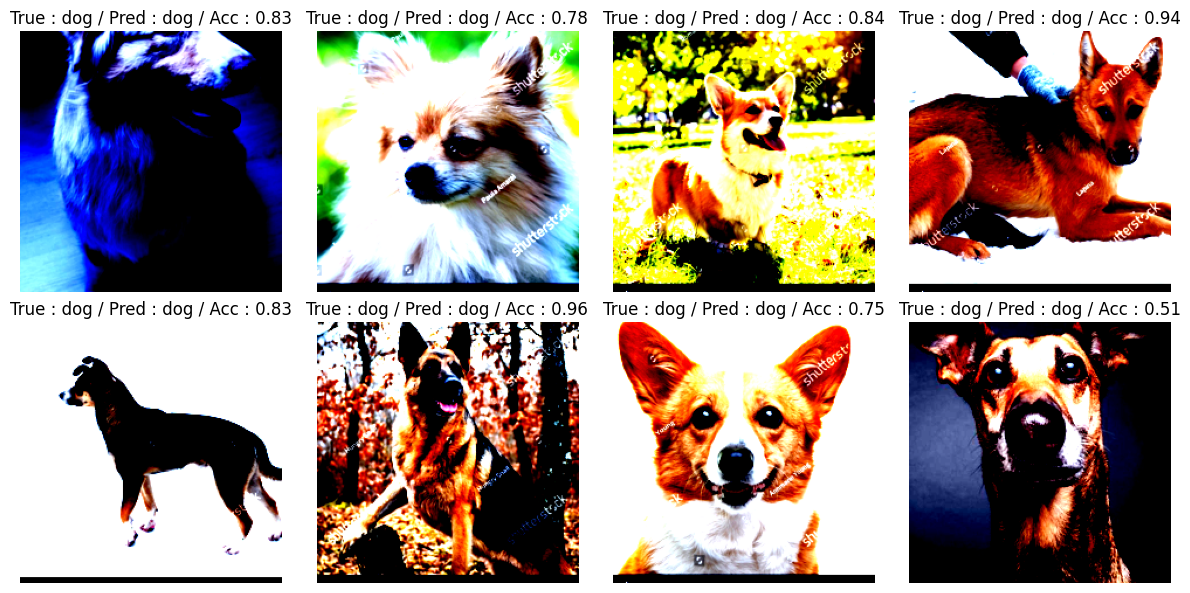

In [26]:
# images, labels = next(iter(test_loader))
batch_size = 8
all_batches = list(test_loader)
images, labels = all_batches[14]  

model.eval()

with torch.no_grad():
    outputs = model(images.to(device))

    prob = torch.softmax(outputs, dim=1)
    confidence, predict = torch.max(prob, 1)

plt.figure(figsize=(12, 6))

for i in range(min(8, len(images))):
    image = images[i].permute(1, 2, 0).numpy() 

    true_label = class_names[labels[i].item()]
    pred_label = class_names[predict[i].item()]

    conf = confidence[i].item()

    # 2행 4열 형태로 이미지출력
    plt.subplot(2, 4, i+ 1)
    plt.imshow(image)
    plt.title(f'True : {true_label} / Pred : {pred_label} / Acc : {conf:.2f}')
    plt.axis('off')

plt.tight_layout()
plt.show()